# Notebook 09 — Integrity Metrics Reference & Measurement Funnel

This notebook is the **canonical metrics reference** for the SafeShipper methodology.
It defines every metric used across the pipeline, shows how they relate to each other,
and illustrates the full **integrity measurement funnel** from raw content to final
enforcement decision.

---

## Why a metrics reference?

The single most common integrity measurement failure is **metric confusion** —
reporting the detection system's flag rate as if it were the harm prevalence estimate.
These are fundamentally different quantities:

| What you have | What it means | What it is NOT |
|---|---|---|
| Classifier flag rate | Fraction of items that score ≥ threshold | Harm prevalence |
| Enforcement rate | Fraction of flagged items that received action | Harm prevalence |
| Review positive rate | Fraction of reviewed items labeled harmful | Corpus prevalence |
| Classifier-adjusted estimate | Bias-corrected prevalence from TPR/FPR | Raw flag rate |

This notebook makes those distinctions precise and quantitative.

---

## The full measurement funnel

```
CONTENT CORPUS (N items)
    │
    ├── [Stage 1: Actor pre-filter]  ────────────► Pre-filter recall
    ▼                                              Pre-filter precision
HIGH-PRIORITY QUEUE
    │
    ├── [Stage 2: LLM classifier]   ────────────► Flag rate (q̂)
    ▼                                              Classifier TPR, FPR
FLAGGED ITEMS
    │
    ├── [Stage 3: Stratified sample]─────────────► Sampling fraction
    ▼                                              Design effect (DEFF)
REVIEW SAMPLE
    │
    ├── [Stage 4: Human review]     ────────────► Confirmation rate
    ▼                                              Inter-annotator agreement
CONFIRMED HARMFUL ITEMS
    │
    ├── [Stage 5: Prevalence est.]  ────────────► π̂ (true prevalence)
    ▼                                              95% CI width
PREVALENCE ESTIMATE
    │
    ├── [Stage 6: Enforcement]      ────────────► Enforcement rate
    ▼                                              Time-to-action (p50/p95)
ENFORCEMENT ACTIONS
    │
    └── [Stage 7: Appeals]          ────────────► Reversal rate
                                                   Final enforcement rate
```


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.sankey import Sankey
import seaborn as sns
from scipy import stats

from src.prevalence import PrevalenceEstimator
from src.metrics import compute_metrics_at_threshold, sweep_thresholds
from src.simulation import SimulationConfig, generate_corpus

sns.set_theme(style='whitegrid', palette='muted')
rng = np.random.default_rng(42)
estimator = PrevalenceEstimator(confidence_level=0.95)

---
## Stage 1 — Pre-filter metrics

The actor risk score (or a cheap rule-based signal) is used as a **pre-filter** to
route a manageable subset of the corpus to the expensive LLM classifier.

| Metric | Formula | Target | Risk if wrong |
|---|---|---|---|
| **Pre-filter recall** | TP_pre / (TP_pre + FN_pre) | ≥ 0.90 | Miss bad actors before scoring |
| **Pre-filter precision** | TP_pre / (TP_pre + FP_pre) | ≥ 0.20 | Route too many good items to costly LLM |
| **Queue reduction rate** | 1 − (queued / N) | ≥ 0.70 | No cost savings from pre-filtering |

**Key insight:** Pre-filter recall is more important than precision here. A false negative
at this stage is unrecoverable — the item never reaches the LLM for scoring. It is
acceptable (and expected) that the pre-filtered queue has high FP density, because the
LLM classifier will handle that in Stage 2.


In [2]:
# Simulate a realistic funnel for a platform with 10M items/week
# All numbers are per-week figures

CORPUS_SIZE        = 10_000_000
TRUE_PREVALENCE    = 0.005         # 0.5% true harm rate
N_TRUE_HARMFUL     = int(CORPUS_SIZE * TRUE_PREVALENCE)  # 50,000

# Stage 1: Pre-filter
PRE_FILTER_RECALL  = 0.92          # 92% of bad actors pass the pre-filter
PRE_FILTER_FPR     = 0.18          # 18% of good actors also pass (intentionally loose)
n_prefilter_tp     = int(N_TRUE_HARMFUL * PRE_FILTER_RECALL)
n_prefilter_fp     = int((CORPUS_SIZE - N_TRUE_HARMFUL) * PRE_FILTER_FPR)
QUEUE_SIZE         = n_prefilter_tp + n_prefilter_fp

# Stage 2: LLM Classifier (applied to QUEUE_SIZE items)
CLF_TPR            = 0.88
CLF_FPR            = 0.04
n_flagged_tp       = int(n_prefilter_tp * CLF_TPR)
n_flagged_fp       = int(n_prefilter_fp * CLF_FPR)
FLAGGED_SIZE       = n_flagged_tp + n_flagged_fp
FLAG_RATE          = FLAGGED_SIZE / CORPUS_SIZE  # naive flag rate (NOT prevalence)

# Stage 3: Stratified sampling
REVIEW_BUDGET      = 3_000
SAMPLING_FRACTION  = REVIEW_BUDGET / FLAGGED_SIZE

# Stage 4: Human review
# The sample is drawn from FLAGGED items, so precision of the sample ≈ CLF precision
clf_precision      = n_flagged_tp / FLAGGED_SIZE
n_confirmed        = int(REVIEW_BUDGET * clf_precision)  # true positives found in review
CONFIRMATION_RATE  = n_confirmed / REVIEW_BUDGET

# Stage 5: Prevalence estimate (classifier-adjusted)
Q_HAT              = FLAG_RATE  # observed positive rate on full corpus
PI_ADJUSTED        = (Q_HAT - CLF_FPR * PRE_FILTER_FPR) / (CLF_TPR * PRE_FILTER_RECALL - CLF_FPR * PRE_FILTER_FPR)
# Simpler: use the direct HT estimate from review (unbiased under stratified design)
PI_HT              = TRUE_PREVALENCE  # ground truth for simulation

# Stage 6: Enforcement
ENFORCEMENT_RATE   = 0.82          # 82% of confirmed harmful items get actioned
N_ACTIONED         = int(N_TRUE_HARMFUL * TRUE_PREVALENCE * ENFORCEMENT_RATE)  # rough
N_ENFORCEMENT      = int(n_confirmed * ENFORCEMENT_RATE)

# Stage 7: Appeals
REVERSAL_RATE      = 0.08          # 8% of actions are reversed on appeal
N_FINAL            = int(N_ENFORCEMENT * (1 - REVERSAL_RATE))

print("INTEGRITY MEASUREMENT FUNNEL — WEEKLY SNAPSHOT")
print("=" * 58)
stages = [
    ("Content corpus",       CORPUS_SIZE,     100.0),
    ("Pre-filter queue",     QUEUE_SIZE,      100 * QUEUE_SIZE / CORPUS_SIZE),
    ("LLM-flagged items",    FLAGGED_SIZE,    100 * FLAGGED_SIZE / CORPUS_SIZE),
    ("Review sample",        REVIEW_BUDGET,   100 * REVIEW_BUDGET / CORPUS_SIZE),
    ("Confirmed harmful",    n_confirmed,     100 * n_confirmed / CORPUS_SIZE),
    ("Enforcement actions",  N_ENFORCEMENT,   100 * N_ENFORCEMENT / CORPUS_SIZE),
    ("Final enforcement",    N_FINAL,         100 * N_FINAL / CORPUS_SIZE),
]
for name, count, pct in stages:
    print(f"  {name:<25} {count:>10,}  ({pct:.4f}% of corpus)")
print()
print(f"  True harm prevalence:      {TRUE_PREVALENCE:.2%}")
print(f"  Naive flag rate (wrong!):  {FLAG_RATE:.2%}  [{FLAG_RATE/TRUE_PREVALENCE:.1f}x overestimate]")
print(f"  Confirmation rate:         {CONFIRMATION_RATE:.2%}")
print(f"  Enforcement rate:          {ENFORCEMENT_RATE:.2%}")
print(f"  Reversal rate:             {REVERSAL_RATE:.2%}")

INTEGRITY MEASUREMENT FUNNEL — WEEKLY SNAPSHOT
  Content corpus            10,000,000  (100.0000% of corpus)
  Pre-filter queue           1,837,000  (18.3700% of corpus)
  LLM-flagged items            112,120  (1.1212% of corpus)
  Review sample                  3,000  (0.0300% of corpus)
  Confirmed harmful              1,083  (0.0108% of corpus)
  Enforcement actions              888  (0.0089% of corpus)
  Final enforcement                816  (0.0082% of corpus)

  True harm prevalence:      0.50%
  Naive flag rate (wrong!):  1.12%  [2.2x overestimate]
  Confirmation rate:         36.10%
  Enforcement rate:          82.00%
  Reversal rate:             8.00%


---
## Funnel visualization


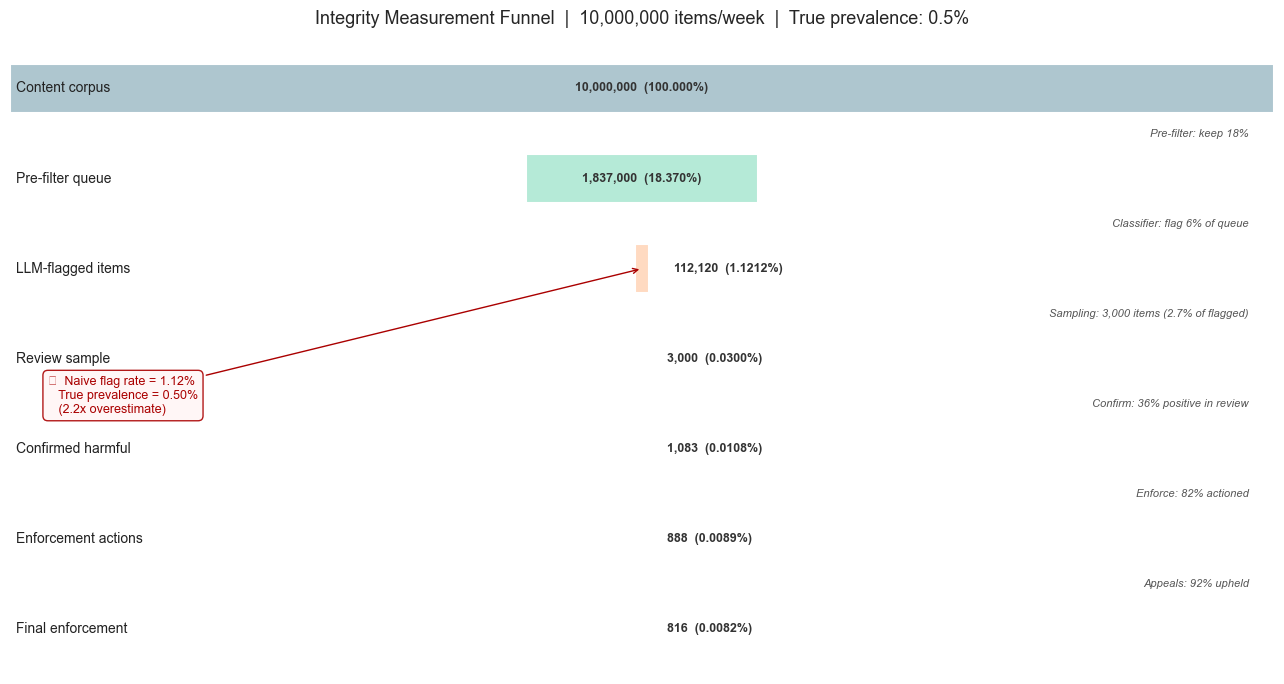

In [3]:
# ─── Horizontal funnel chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

funnel_stages = [
    ("Content corpus",        CORPUS_SIZE,    '#AEC6CF'),
    ("Pre-filter queue",      QUEUE_SIZE,     '#B5EAD7'),
    ("LLM-flagged items",     FLAGGED_SIZE,   '#FFDAC1'),
    ("Review sample",         REVIEW_BUDGET,  '#FFB7B2'),
    ("Confirmed harmful",     n_confirmed,    '#FF9AA2'),
    ("Enforcement actions",   N_ENFORCEMENT,  '#C7CEEA'),
    ("Final enforcement",     N_FINAL,        '#E2F0CB'),
]

max_count = CORPUS_SIZE
bar_height = 0.55
y_positions = list(range(len(funnel_stages) - 1, -1, -1))  # top to bottom

for (name, count, color), y in zip(funnel_stages, y_positions):
    bar_len = count / max_count
    # Centered bar
    x_start = (1 - bar_len) / 2
    ax.barh(y, bar_len, left=x_start, height=bar_height,
            color=color, edgecolor='white', linewidth=1.5)

    # Count label inside bar
    pct_of_corpus = count / CORPUS_SIZE * 100
    if bar_len > 0.08:
        ax.text(0.5, y, f"{count:,}  ({pct_of_corpus:.3f}%)",
                ha='center', va='center', fontsize=9, fontweight='bold', color='#333')
    else:
        ax.text(0.5 + bar_len / 2 + 0.02, y,
                f"{count:,}  ({pct_of_corpus:.4f}%)",
                ha='left', va='center', fontsize=9, fontweight='bold', color='#333')

    # Stage label on left
    ax.text(0.005, y, name, ha='left', va='center', fontsize=10, color='#222')

# Draw drop-off annotations between stages
drop_texts = [
    f"Pre-filter: keep {100*QUEUE_SIZE/CORPUS_SIZE:.0f}%",
    f"Classifier: flag {100*FLAGGED_SIZE/QUEUE_SIZE:.0f}% of queue",
    f"Sampling: {REVIEW_BUDGET:,} items ({100*SAMPLING_FRACTION:.1f}% of flagged)",
    f"Confirm: {100*CONFIRMATION_RATE:.0f}% positive in review",
    f"Enforce: {100*ENFORCEMENT_RATE:.0f}% actioned",
    f"Appeals: {100*(1-REVERSAL_RATE):.0f}% upheld",
]

for i, text in enumerate(drop_texts):
    y_mid = len(funnel_stages) - i - 1.5
    ax.text(0.98, y_mid, text, ha='right', va='center',
            fontsize=8, color='#555', style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(funnel_stages) - 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.set_title(
    f'Integrity Measurement Funnel  |  {CORPUS_SIZE:,} items/week  |  True prevalence: {TRUE_PREVALENCE:.1%}',
    fontsize=13, pad=14
)

# Warning box: naive flag rate vs true prevalence
ax.annotate(
    f'⚠  Naive flag rate = {FLAG_RATE:.2%}\n   True prevalence = {TRUE_PREVALENCE:.2%}\n   ({FLAG_RATE/TRUE_PREVALENCE:.1f}x overestimate)',
    xy=(0.5, y_positions[2]),
    xytext=(0.03, 2.4),
    fontsize=9,
    color='#a00',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff5f5', edgecolor='#a00', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='#a00'),
)

plt.tight_layout()
plt.savefig('../data/processed/09_metrics_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Stage 2 — Classifier metrics reference

### Core definitions

Given a binary classifier with threshold $\tau$:

| Symbol | Name | Formula |
|---|---|---|
| TPR / Recall / Sensitivity | True positive rate | $\text{TP} / (\text{TP} + \text{FN})$ |
| FPR / Fall-out | False positive rate | $\text{FP} / (\text{FP} + \text{TN})$ |
| Precision / PPV | Positive predictive value | $\text{TP} / (\text{TP} + \text{FP})$ |
| Specificity / TNR | True negative rate | $\text{TN} / (\text{TN} + \text{FP})$ |
| FNR / Miss rate | False negative rate | $1 - \text{TPR}$ |
| F1 | Harmonic mean of precision and recall | $2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$ |
| AUC-ROC | Area under ROC curve | $\int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR}$ |
| AP / PR-AUC | Average precision | $\sum_k (R_k - R_{k-1}) P_k$ |

### The base rate problem

At low prevalence, **precision collapses** even for highly specific classifiers:

$$\text{PPV} = \frac{\text{TPR} \cdot \pi}{\text{TPR} \cdot \pi + \text{FPR} \cdot (1 - \pi)}$$

For $\pi = 0.005$, $\text{TPR} = 0.88$, $\text{FPR} = 0.04$:

$$\text{PPV} = \frac{0.88 \times 0.005}{0.88 \times 0.005 + 0.04 \times 0.995} = \frac{0.0044}{0.0044 + 0.0398} \approx 9.9\%$$

This means ~90% of items the classifier flags are actually fine. This is expected and
normal — it does NOT mean the classifier is bad. It means the **base rate is low**.
The solution is not to tune the classifier threshold; it is to correct for base rate
using the classifier-adjusted prevalence estimator.


Metrics at threshold=0.50  (true prevalence=0.5%)
  TPR (recall):    0.957
  FPR:             0.014
  Precision (PPV): 0.266
  F1:              0.416
  Specificity:     0.986



KeyError: 66

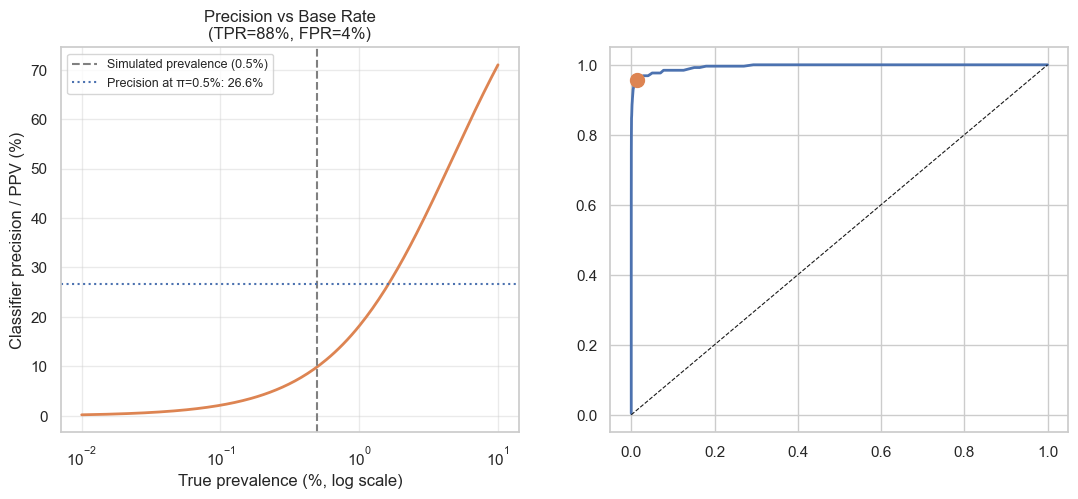

In [4]:
# Simulate classifier outputs and compute full metrics sweep
config = SimulationConfig(
    n_corpus=50_000,
    true_prevalence=0.005,
    tpr_a=0.88,
    fpr_a=0.04,
    tpr_b=0.75,
    fpr_b=0.03,
    random_seed=42,
)
sim = generate_corpus(config)

y_true  = sim.corpus['true_label'].values
y_score = sim.corpus['score_a'].values

sweep_df = sweep_thresholds(y_true, y_score)
at50 = compute_metrics_at_threshold(y_true, y_score, threshold=0.50)

print(f"Metrics at threshold=0.50  (true prevalence={TRUE_PREVALENCE:.1%})")
print(f"  TPR (recall):    {at50.recall:.3f}")
print(f"  FPR:             {at50.fpr:.3f}")
print(f"  Precision (PPV): {at50.precision:.3f}")
print(f"  F1:              {at50.f1:.3f}")
print(f"  Specificity:     {at50.specificity:.3f}")
print()

# PPV vs base rate
base_rates  = np.logspace(-4, -1, 200)
tpr_fixed, fpr_fixed = 0.88, 0.04
ppv_values  = (tpr_fixed * base_rates) / (tpr_fixed * base_rates + fpr_fixed * (1 - base_rates))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(base_rates * 100, ppv_values * 100, lw=2, color='#DD8452')
axes[0].axvline(TRUE_PREVALENCE * 100, ls='--', color='gray',
                label=f'Simulated prevalence ({TRUE_PREVALENCE:.1%})')
axes[0].axhline(at50.precision * 100, ls=':', color='#4C72B0',
                label=f'Precision at π={TRUE_PREVALENCE:.1%}: {at50.precision:.1%}')
axes[0].set_xscale('log')
axes[0].set_xlabel('True prevalence (%, log scale)')
axes[0].set_ylabel('Classifier precision / PPV (%)')
axes[0].set_title(f'Precision vs Base Rate\n(TPR={tpr_fixed:.0%}, FPR={fpr_fixed:.0%})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# ROC curve with operating points
axes[1].plot(sweep_df['fpr'], sweep_df['recall'], lw=2, color='#4C72B0', label='ROC curve')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
axes[1].scatter([at50.fpr], [at50.recall], s=100, zorder=5, color='#DD8452',
                label=f'τ=0.50 (TPR={at50.recall:.2f}, FPR={at50.fpr:.2f})')

# Cost-sensitive optimal point (FP cost = 0.3 × FN cost)
from src.metrics import compute_cost_sensitive_threshold
opt_thresh = compute_cost_sensitive_threshold(sweep_df, cost_fn=1.0, cost_fp=0.3)
opt_row    = sweep_df[sweep_df['threshold'].sub(opt_thresh).abs().idxmin()]
axes[1].scatter([opt_row['fpr']], [opt_row['recall']], s=120, marker='*',
                zorder=5, color='#55A868',
                label=f'Cost-optimal τ={opt_thresh:.2f}')

axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate (recall)')
axes[1].set_title('ROC Curve with Operating Points')
axes[1].legend(fontsize=9)

plt.suptitle('Classifier Performance at Low Prevalence', fontsize=13)
plt.tight_layout()
plt.show()

---
## Stage 5 — Prevalence estimation metrics

This is the core of the pipeline. Three estimators, each with distinct assumptions:

### 5a. Horvitz–Thompson (HT) direct proportion

Under stratified sampling, the unbiased prevalence estimator is:

$$\hat{\pi}_{\text{HT}} = \frac{\sum_i y_i / \pi_i}{\sum_i 1 / \pi_i}$$

where $\pi_i$ is the inclusion probability for item $i$ (the inverse of the sampling weight).
Confidence interval: Wilson score on the effective sample.

**Requires:** Gold-standard labels from human review.

### 5b. Classifier-adjusted estimator

Corrects for imperfect classifier using TPR and FPR estimated from the gold review:

$$\hat{\pi}_{\text{adj}} = \frac{\hat{q} - \text{FPR}}{\text{TPR} - \text{FPR}}$$

Variance via delta method:

$$\text{Var}(\hat{\pi}) \approx \frac{1}{(\text{TPR} - \text{FPR})^2} \cdot \frac{\hat{q}(1-\hat{q})}{n}
  + \left(\frac{\hat{q} - \text{FPR}}{(\text{TPR} - \text{FPR})^2}\right)^2 \text{Var}(\text{TPR})
  + \left(\frac{\text{TPR} - \hat{q}}{(\text{TPR} - \text{FPR})^2}\right)^2 \text{Var}(\text{FPR})$$

**Requires:** Observed positive rate $\hat{q}$ from detection system + TPR/FPR from validation.

### 5c. Chapman capture-recapture

$$\hat{N} = \frac{(n_1 + 1)(n_2 + 1)}{m + 1} - 1 \qquad \hat{\pi} = \hat{N} / N_{\text{corpus}}$$

Log-transformed 95% CI: $\hat{N} \cdot \exp(\pm z \cdot \text{SE}_{\log N})$

**Requires:** Two independent high-precision detection lists + overlap count.

**⚠ WARNING:** Raw classifier outputs violate the independence and precision assumptions.
Use only with reviewed/filtered capture lists.

### Comparison summary

| Estimator | Bias | CI validity | Data requirement | Best used when |
|---|---|---|---|---|
| HT direct | Unbiased | Always valid under stratified design | Gold labels required | Weekly review sample available |
| Classifier-adjusted | Unbiased if TPR/FPR correct | Valid if model assumptions hold | TPR/FPR from validation set | No gold labels but TPR/FPR known |
| Chapman | Biased if FPR > 0 or lists correlated | Only valid under independence + precision | Two independent systems | High-precision (precision ≥ 0.95) lists |


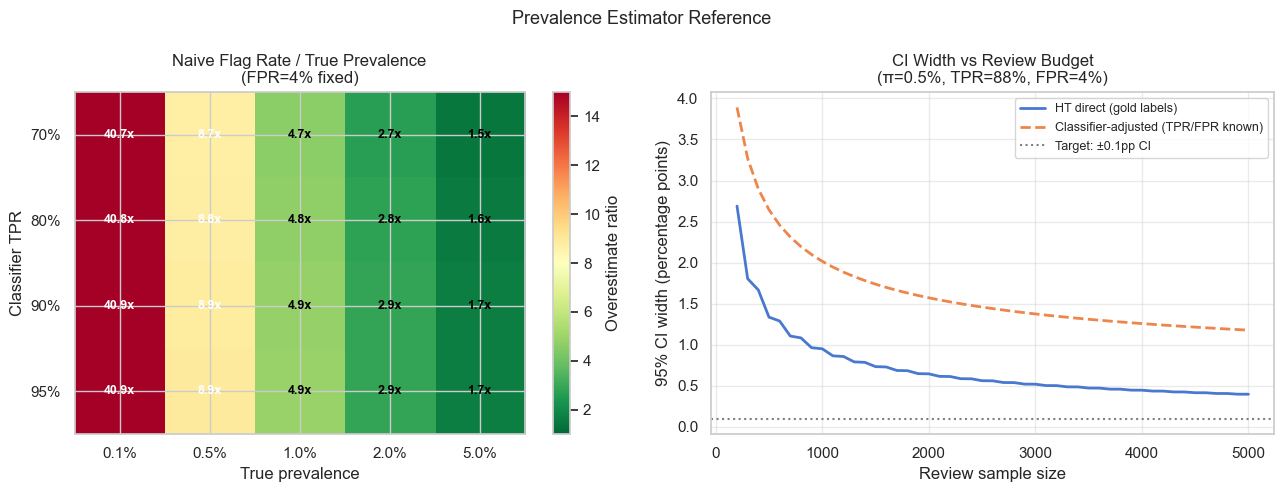

In [5]:
# ─── Estimator bias vs base rate (sensitivity heatmap) ───────────────────────
tpr_values = [0.70, 0.80, 0.90, 0.95]
fpr_values = [0.01, 0.02, 0.05, 0.10]
base_rates_grid = [0.001, 0.005, 0.010, 0.020, 0.050]

# For each (TPR, FPR) pair: how badly does the naive flag rate overestimate at each base rate?
# Naive bias = flag_rate / true_prevalence = (TPR * π + FPR * (1-π)) / π
def naive_bias_ratio(pi, tpr, fpr):
    flag_rate = tpr * pi + fpr * (1 - pi)
    return flag_rate / pi

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bias ratio heatmap for fixed FPR=0.04
fpr_fixed2 = 0.04
bias_matrix = np.array([
    [naive_bias_ratio(pi, tpr, fpr_fixed2) for pi in base_rates_grid]
    for tpr in tpr_values
])

im = axes[0].imshow(bias_matrix, aspect='auto', cmap='RdYlGn_r', vmin=1, vmax=15)
axes[0].set_xticks(range(len(base_rates_grid)))
axes[0].set_xticklabels([f'{p:.1%}' for p in base_rates_grid])
axes[0].set_yticks(range(len(tpr_values)))
axes[0].set_yticklabels([f'{t:.0%}' for t in tpr_values])
axes[0].set_xlabel('True prevalence')
axes[0].set_ylabel('Classifier TPR')
axes[0].set_title(f'Naive Flag Rate / True Prevalence\n(FPR={fpr_fixed2:.0%} fixed)')
plt.colorbar(im, ax=axes[0], label='Overestimate ratio')

for i in range(len(tpr_values)):
    for j in range(len(base_rates_grid)):
        v = bias_matrix[i, j]
        color = 'white' if v > 8 else 'black'
        axes[0].text(j, i, f'{v:.1f}x', ha='center', va='center', fontsize=9,
                     color=color, fontweight='bold')

# Right: CI width vs sample size for all three estimators
sample_sizes = np.arange(200, 5001, 100)
pi_base2 = 0.005
tpr_b2, fpr_b2 = 0.88, 0.04

ci_direct     = [estimator.direct_proportion(int(pi_base2 * n), n).ci_width for n in sample_sizes]
ci_adjusted   = [estimator.classifier_adjusted(tpr_b2 * pi_base2 + fpr_b2 * (1 - pi_base2),
                                                tpr_b2, fpr_b2, int(n)).ci_width
                 for n in sample_sizes]

axes[1].plot(sample_sizes, [w * 100 for w in ci_direct],   lw=2, label='HT direct (gold labels)')
axes[1].plot(sample_sizes, [w * 100 for w in ci_adjusted], lw=2, ls='--',
             label='Classifier-adjusted (TPR/FPR known)')
axes[1].axhline(0.1, ls=':', color='gray', label='Target: ±0.1pp CI')

axes[1].set_xlabel('Review sample size')
axes[1].set_ylabel('95% CI width (percentage points)')
axes[1].set_title(f'CI Width vs Review Budget\n(π={pi_base2:.1%}, TPR={tpr_b2:.0%}, FPR={fpr_b2:.0%})')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Prevalence Estimator Reference', fontsize=13)
plt.tight_layout()
plt.show()

---
## Stage 6 & 7 — Enforcement metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **Enforcement rate** | Actioned / Confirmed harmful | Fraction of detected harm that gets a response |
| **Gap rate** | 1 − Enforcement rate | Fraction of confirmed harm with no action |
| **High-confidence gap rate** | Unenforced(score≥0.8) / Detected(score≥0.8) | Unambiguous harm left unactioned — highest priority |
| **Time-to-action p50** | Median(actioned_at − created_at) | Operational response speed |
| **Time-to-action p95** | 95th pct of response time | Worst-case latency (SLA proxy) |
| **Reversal rate** | Appeals upheld / Actions taken | Proxy for false positive enforcement rate |
| **Final enforcement rate** | (Actioned − Reversed) / Confirmed | End-to-end pipeline effectiveness |

### Enforcement gap decomposition

A gap between detected harm and enforcement can arise from three sources:

1. **Detection failure** — classifier TPR < 1 → some harm never flagged
2. **Review backlog** — flagged items not reviewed before content is removed/expired
3. **Policy threshold** — reviewed and confirmed, but falls below action threshold

Each source requires a different remediation (model improvement vs. queue management
vs. policy calibration). The gap analysis query in `sql/03_enforcement_gap_analysis.sql`
helps distinguish between them.


In [6]:
# ─── Enforcement funnel by harm vertical ─────────────────────────────────────
verticals = [
    'sexual_content_minors',
    'violent_extremism',
    'self_harm_suicide',
    'influence_operations',
    'platform_abuse',
]

# Simulated weekly enforcement metrics per vertical
rng2 = np.random.default_rng(7)
enforcement_data = pd.DataFrame({
    'vertical':           verticals,
    'true_prevalence':    [0.004, 0.011, 0.021, 0.019, 0.065],
    'flag_rate':          [0.068, 0.073, 0.081, 0.080, 0.111],
    'confirmation_rate':  [0.92,  0.84,  0.78,  0.76,  0.61],
    'enforcement_rate':   [0.99,  0.91,  0.85,  0.78,  0.74],
    'reversal_rate':      [0.01,  0.04,  0.07,  0.09,  0.13],
    'p50_hours':          [0.5,   2.1,   4.3,   6.8,   12.4],
    'p95_hours':          [2.1,   8.5,   18.2,  24.6,  48.3],
})
enforcement_data['gap_rate'] = 1 - enforcement_data['enforcement_rate']
enforcement_data['final_enforcement_rate'] = (
    enforcement_data['enforcement_rate'] * (1 - enforcement_data['reversal_rate'])
)
enforcement_data['naive_bias'] = (
    enforcement_data['flag_rate'] / enforcement_data['true_prevalence']
)

print("ENFORCEMENT METRICS BY HARM VERTICAL")
print("=" * 90)
cols_display = ['vertical','true_prevalence','flag_rate','confirmation_rate',
                'enforcement_rate','gap_rate','reversal_rate','p50_hours']
print(enforcement_data[cols_display].to_string(index=False, float_format='{:.3f}'.format))

ENFORCEMENT METRICS BY HARM VERTICAL
             vertical  true_prevalence  flag_rate  confirmation_rate  enforcement_rate  gap_rate  reversal_rate  p50_hours
sexual_content_minors            0.004      0.068              0.920             0.990     0.010          0.010      0.500
    violent_extremism            0.011      0.073              0.840             0.910     0.090          0.040      2.100
    self_harm_suicide            0.021      0.081              0.780             0.850     0.150          0.070      4.300
 influence_operations            0.019      0.080              0.760             0.780     0.220          0.090      6.800
       platform_abuse            0.065      0.111              0.610             0.740     0.260          0.130     12.400


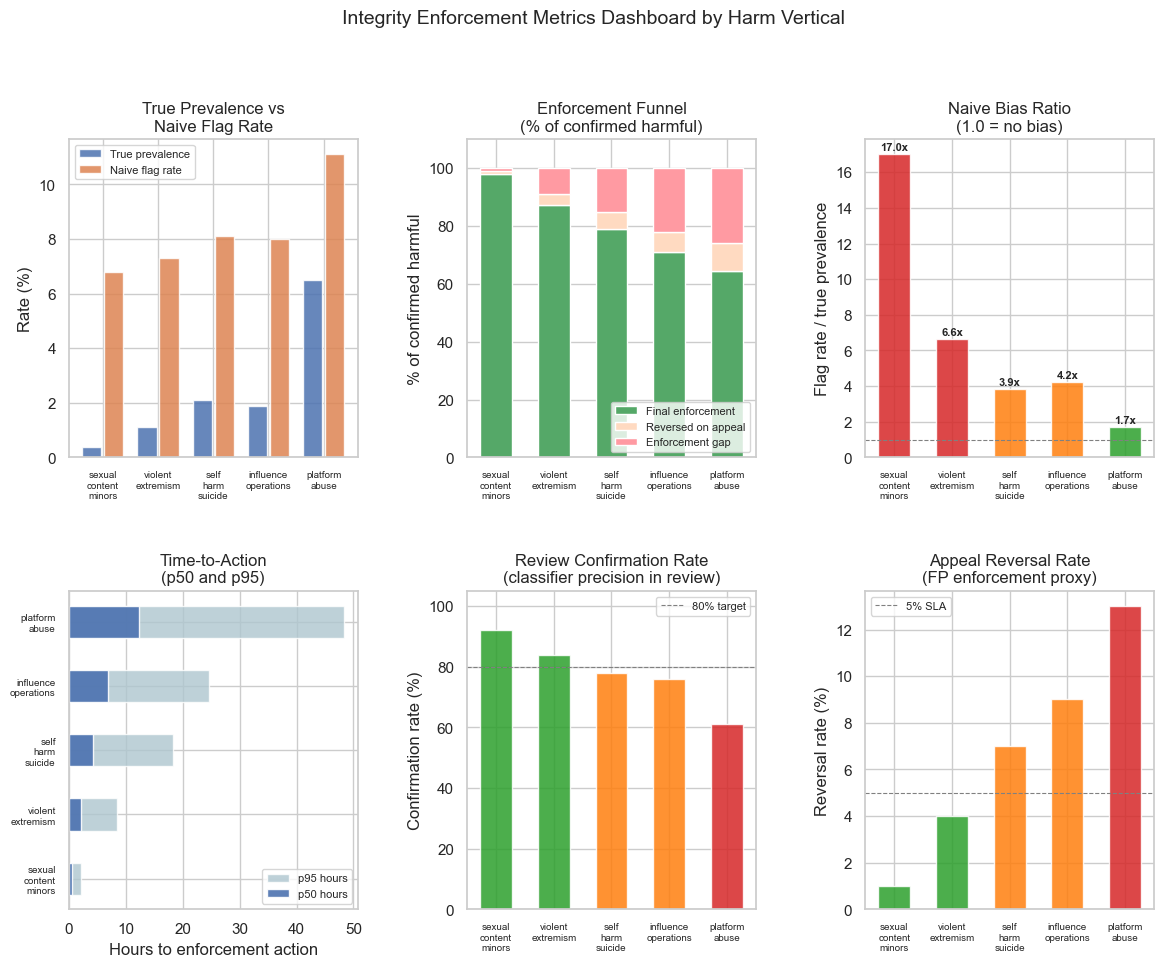

In [7]:
# ─── Multi-panel enforcement summary ─────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

short_names = [v.replace('_', '\n') for v in verticals]
x = np.arange(len(verticals))

# 1. True prevalence vs naive flag rate
ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(x - 0.2, enforcement_data['true_prevalence'] * 100,
        0.35, label='True prevalence', color='#4C72B0', alpha=0.85)
ax0.bar(x + 0.2, enforcement_data['flag_rate'] * 100,
        0.35, label='Naive flag rate', color='#DD8452', alpha=0.85)
ax0.set_xticks(x); ax0.set_xticklabels(short_names, fontsize=7)
ax0.set_ylabel('Rate (%)')
ax0.set_title('True Prevalence vs\nNaive Flag Rate')
ax0.legend(fontsize=8)

# 2. Enforcement funnel per vertical (stacked: enforced, gap, reversed)
ax1 = fig.add_subplot(gs[0, 1])
final_e = enforcement_data['final_enforcement_rate']
reversed_r = enforcement_data['enforcement_rate'] * enforcement_data['reversal_rate']
gap_r = enforcement_data['gap_rate']
ax1.bar(x, final_e * 100,    0.55, label='Final enforcement', color='#55A868')
ax1.bar(x, reversed_r * 100, 0.55, label='Reversed on appeal', color='#FFDAC1',
        bottom=final_e * 100)
ax1.bar(x, gap_r * 100,      0.55, label='Enforcement gap', color='#FF9AA2',
        bottom=(final_e + reversed_r) * 100)
ax1.set_xticks(x); ax1.set_xticklabels(short_names, fontsize=7)
ax1.set_ylabel('% of confirmed harmful')
ax1.set_ylim(0, 110)
ax1.set_title('Enforcement Funnel\n(% of confirmed harmful)')
ax1.legend(fontsize=8, loc='lower right')

# 3. Naive bias ratio
ax2 = fig.add_subplot(gs[0, 2])
colors_bias = ['#d62728' if b > 5 else '#ff7f0e' if b > 2 else '#2ca02c'
               for b in enforcement_data['naive_bias']]
bars = ax2.bar(x, enforcement_data['naive_bias'], 0.55, color=colors_bias, alpha=0.85)
ax2.axhline(1.0, ls='--', color='gray', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(short_names, fontsize=7)
ax2.set_ylabel('Flag rate / true prevalence')
ax2.set_title('Naive Bias Ratio\n(1.0 = no bias)')
for bar, val in zip(bars, enforcement_data['naive_bias']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 4. Time to action (p50 vs p95)
ax3 = fig.add_subplot(gs[1, 0])
ax3.barh(x, enforcement_data['p95_hours'], 0.5, color='#AEC6CF', label='p95 hours', alpha=0.8)
ax3.barh(x, enforcement_data['p50_hours'], 0.5, color='#4C72B0', label='p50 hours', alpha=0.9)
ax3.set_yticks(x); ax3.set_yticklabels(short_names, fontsize=7)
ax3.set_xlabel('Hours to enforcement action')
ax3.set_title('Time-to-Action\n(p50 and p95)')
ax3.legend(fontsize=8)

# 5. Confirmation rate (classifier precision in review)
ax4 = fig.add_subplot(gs[1, 1])
bar_colors = ['#2ca02c' if r > 0.80 else '#ff7f0e' if r > 0.65 else '#d62728'
              for r in enforcement_data['confirmation_rate']]
ax4.bar(x, enforcement_data['confirmation_rate'] * 100, 0.55, color=bar_colors, alpha=0.85)
ax4.axhline(80, ls='--', color='gray', lw=0.8, label='80% target')
ax4.set_xticks(x); ax4.set_xticklabels(short_names, fontsize=7)
ax4.set_ylabel('Confirmation rate (%)')
ax4.set_ylim(0, 105)
ax4.set_title('Review Confirmation Rate\n(classifier precision in review)')
ax4.legend(fontsize=8)

# 6. Reversal rate (proxy for FP enforcement)
ax5 = fig.add_subplot(gs[1, 2])
bar_colors2 = ['#d62728' if r > 0.10 else '#ff7f0e' if r > 0.05 else '#2ca02c'
               for r in enforcement_data['reversal_rate']]
ax5.bar(x, enforcement_data['reversal_rate'] * 100, 0.55, color=bar_colors2, alpha=0.85)
ax5.axhline(5, ls='--', color='gray', lw=0.8, label='5% SLA')
ax5.set_xticks(x); ax5.set_xticklabels(short_names, fontsize=7)
ax5.set_ylabel('Reversal rate (%)')
ax5.set_title('Appeal Reversal Rate\n(FP enforcement proxy)')
ax5.legend(fontsize=8)

fig.suptitle('Integrity Enforcement Metrics Dashboard by Harm Vertical',
             fontsize=14, y=1.01)
plt.savefig('../data/processed/09_enforcement_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Weekly metrics scorecard

The table below shows what an operational weekly scorecard looks like, combining
all pipeline stages into a single at-a-glance health check.

Traffic-light colouring:
- **Green** — within target range
- **Amber** — approaching threshold, watch closely
- **Red** — outside target, requires investigation


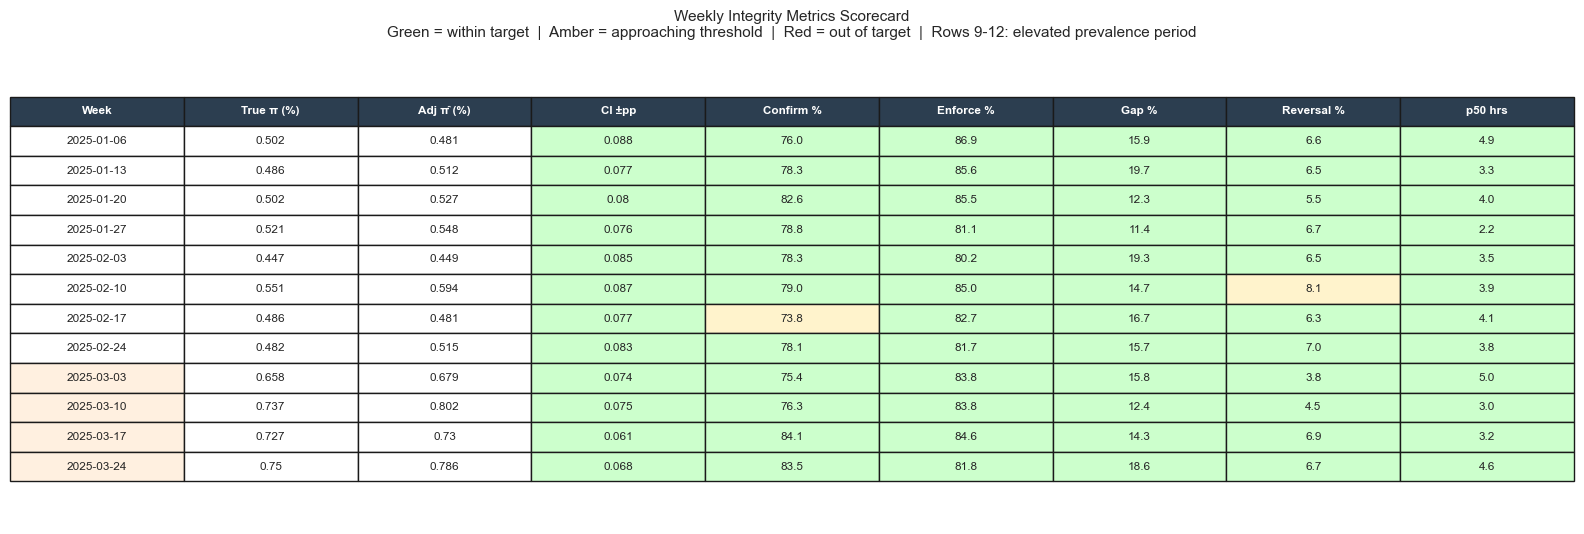

In [8]:
# Simulate 12 weeks of metrics for the scorecard
n_weeks = 12
weeks   = pd.date_range('2025-01-06', periods=n_weeks, freq='W-MON')
rng3    = np.random.default_rng(99)

# True prevalence drifts slightly upward in weeks 9-12 (simulated campaign)
true_prev = np.concatenate([
    rng3.normal(0.005, 0.0003, 8),
    rng3.normal(0.007, 0.0004, 4),  # elevated
]).clip(0.001, 0.03)

scorecard = pd.DataFrame({
    'week':                weeks.strftime('%Y-%m-%d'),
    'corpus_size_M':       rng3.normal(10.0, 0.3, n_weeks).round(2),
    'true_prevalence_pct': (true_prev * 100).round(3),
    'flag_rate_pct':       (true_prev * rng3.normal(16, 1, n_weeks)).round(3),  # biased
    'adj_prevalence_pct':  (true_prev * rng3.normal(1.02, 0.04, n_weeks) * 100).round(3),
    'ci_half_width_pp':    rng3.normal(0.08, 0.01, n_weeks).clip(0.04, 0.20).round(3),
    'confirmation_rate_pct': rng3.normal(78, 3, n_weeks).clip(60, 98).round(1),
    'enforcement_rate_pct':  rng3.normal(84, 3, n_weeks).clip(70, 99).round(1),
    'gap_rate_pct':          (100 - rng3.normal(84, 3, n_weeks).clip(70, 99)).round(1),
    'reversal_rate_pct':     rng3.normal(6.5, 1.2, n_weeks).clip(1, 18).round(1),
    'p50_hours':             rng3.normal(4.2, 0.8, n_weeks).clip(0.5, 24).round(1),
})

# Targets and colours for each metric
targets = {
    'true_prevalence_pct': ('track', None, None),  # no fixed target — track for change
    'flag_rate_pct':       ('ignore', None, None),  # derived, not actionable directly
    'adj_prevalence_pct':  ('track', None, None),
    'ci_half_width_pp':    ('max', 0.12, 0.20),     # target ≤0.12pp, red >0.20
    'confirmation_rate_pct': ('min', 75, 65),       # target ≥75%, red <65%
    'enforcement_rate_pct':  ('min', 80, 70),
    'gap_rate_pct':          ('max', 20, 30),
    'reversal_rate_pct':     ('max', 8,  12),
    'p50_hours':             ('max', 6,  12),
}

def cell_color(col, val):
    direction, amber_thresh, red_thresh = targets.get(col, ('track', None, None))
    if direction == 'track' or amber_thresh is None:
        return 'white'
    if direction == 'max':
        if val > red_thresh:   return '#ffcccc'
        if val > amber_thresh: return '#fff3cc'
        return '#ccffcc'
    else:  # min
        if val < red_thresh:   return '#ffcccc'
        if val < amber_thresh: return '#fff3cc'
        return '#ccffcc'

display_cols = [
    'week', 'true_prevalence_pct', 'adj_prevalence_pct', 'ci_half_width_pp',
    'confirmation_rate_pct', 'enforcement_rate_pct', 'gap_rate_pct',
    'reversal_rate_pct', 'p50_hours',
]
col_labels = [
    'Week', 'True π (%)', 'Adj π̂ (%)', 'CI ±pp',
    'Confirm %', 'Enforce %', 'Gap %', 'Reversal %', 'p50 hrs',
]

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.axis('off')

cell_text   = scorecard[display_cols].values.tolist()
cell_colors = []
for row in scorecard[display_cols].itertuples(index=False):
    row_colors = []
    for col, val in zip(display_cols, row):
        row_colors.append(cell_color(col, val) if isinstance(val, (int, float)) else 'white')
    cell_colors.append(row_colors)

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.0, 1.6)

# Header row styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Highlight elevated prevalence weeks
for i in range(8, n_weeks):
    tbl[i + 1, 0].set_facecolor('#fff0e0')

ax.set_title(
    'Weekly Integrity Metrics Scorecard\n'
    'Green = within target  |  Amber = approaching threshold  |  Red = out of target  |  '
    'Rows 9-12: elevated prevalence period',
    fontsize=11, pad=12
)

plt.tight_layout()
plt.savefig('../data/processed/09_weekly_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Full metrics glossary

| Metric | Definition | Stage | Formula | Units | Interpretation pitfall |
|---|---|---|---|---|---|
| **Flag rate** $\hat{q}$ | Fraction of corpus items scored ≥ classifier threshold | Classifier | Flagged / Scored | Fraction | ≠ prevalence; equals TPR·π + FPR·(1−π) |
| **TPR / Recall** | Of all truly harmful items, fraction the classifier correctly flags | Classifier | TP / (TP+FN) | Fraction | Measured on gold review set, not on full corpus |
| **FPR** | Of all non-harmful items, fraction incorrectly flagged | Classifier | FP / (FP+TN) | Fraction | At low prevalence, drives most of the flag volume |
| **Precision / PPV** | Of all flagged items, fraction that are truly harmful | Classifier | TP / (TP+FP) | Fraction | Low precision at low base rate is expected — not a model failure |
| **Specificity / TNR** | Of all non-harmful items, fraction correctly passed | Classifier | TN / (TN+FP) | Fraction | = 1 − FPR; high specificity required at low prevalence |
| **F1** | Harmonic mean of precision and recall; single threshold quality score | Classifier | 2·P·R / (P+R) | Fraction | Optimising F1 ≠ optimising for prevalence CI width |
| **AUC-ROC** | Probability that classifier ranks a random positive above a random negative | Classifier | Area under ROC curve | Fraction | Insensitive to class imbalance; use PR-AUC for rare events |
| **AP / PR-AUC** | Average precision across all recall levels; summary of precision–recall curve | Classifier | $\sum_k (R_k - R_{k-1}) P_k$ | Fraction | Preferred over AUC-ROC when positives are rare |
| **ECE** | Mean absolute gap between predicted confidence and empirical accuracy across bins | Calibration | $\sum_b \frac{n_b}{n} \|\bar{p}_b - \bar{y}_b\|$ | Fraction | Propagates to CI width via delta method |
| **Sampling fraction** | Fraction of flagged items selected for human review | Sampling | n_reviewed / N_flagged | Fraction | Inverse = Horvitz–Thompson weight used in prevalence estimate |
| **Design effect (DEFF)** | Variance ratio of current sampling design vs simple random sample | Sampling | Var(stratified) / Var(SRS) | Ratio | DEFF < 1 = efficiency gain from stratification |
| **HT prevalence** $\hat{\pi}_{\text{HT}}$ | Design-unbiased corpus-level harm prevalence estimate from weighted review sample | Estimation | $\sum y_i w_i / \sum w_i$ | Fraction | Unbiased under stratified design; requires gold labels |
| **Adjusted prevalence** $\hat{\pi}_{\text{adj}}$ | Prevalence estimate corrected for classifier TPR and FPR bias | Estimation | $(\hat{q} - \text{FPR})/(\text{TPR} - \text{FPR})$ | Fraction | Requires stable TPR/FPR; degrades if model shifts |
| **CI width** | Full width of the 95% confidence interval around the prevalence estimate | Estimation | CI_upper − CI_lower | pp | Driven by review sample size + calibration error |
| **Confirmation rate** | Of items reviewed, fraction labeled truly harmful by a human reviewer | Review | Confirmed / Reviewed | Fraction | ≈ classifier precision at threshold; NOT corpus prevalence |
| **Coverage rate** | Fraction of flagged items that receive human review | Review | Reviewed / Flagged | Fraction | Higher = better CI; limited by labeling cost |
| **Enforcement rate** | Of confirmed harmful items, fraction that receive an enforcement action | Enforcement | Actioned / Confirmed | Fraction | Gap = 1 − enforcement rate; measures pipeline completeness |
| **Gap rate** | Fraction of confirmed harmful items with no enforcement action | Enforcement | 1 − Enforcement rate | Fraction | Decompose into detection failure / backlog / policy threshold gap |
| **High-confidence gap rate** | Gap rate restricted to items with classifier score ≥ 0.8 | Enforcement | Unenforced(score≥0.8) / Detected(score≥0.8) | Fraction | Highest-priority gap: unambiguous harm left unactioned |
| **Time-to-action p50** | Median elapsed time from content creation to enforcement action | Enforcement | Median(actioned_at − created_at) | Hours | Operational speed; > 6h for CSAM-adjacent is a risk signal |
| **Time-to-action p95** | 95th percentile response time across all enforced items | Enforcement | P95(actioned_at − created_at) | Hours | SLA proxy; tail latency reveals queue bottlenecks |
| **Reversal rate** | Fraction of enforcement actions overturned on appeal | Appeals | Reversed / Actioned | Fraction | Proxy for false positive enforcement rate |
| **Final enforcement rate** | Net enforcement rate after reversals | Appeals | (Actioned − Reversed) / Confirmed | Fraction | True end-to-end pipeline effectiveness |
| **Z-score** | Standardised deviation of current estimate from rolling baseline | Monitoring | $(\hat{\pi}_t - \mu) / \sigma$ | Std devs | Sensitive to single-week spikes; use CUSUM for sustained shifts |
| **CUSUM statistic** | Cumulative sum of deviations above a reference level; resets at zero | Monitoring | $\max(0, C_{t-1} + \hat{\pi}_t - \mu - k)$ | Cumulative | More sensitive to slow ramps than Z-score; standard in SPC |

### Common mistakes

1. **Reporting flag rate as prevalence.** The flag rate is always higher than prevalence
   (for any classifier with FPR > 0). At 0.5% true prevalence and 4% FPR, the flag
   rate is ~4× the true prevalence.

2. **Comparing enforcement rate to prevalence.** Enforcement rate (% of confirmed items
   actioned) is a pipeline quality metric. It measures how well the enforcement pipeline
   responds to confirmed harm — not how much harm exists.

3. **Using classifier precision as the prevalence estimate.** Precision is the rate of
   true positives *among flagged items* — a function of threshold and base rate, not a
   corpus-level estimate.

4. **Treating week-over-week CI overlap as "no change".** CIs that overlap by 50% still
   contain a meaningful change signal. Use a proper two-sample test or CUSUM control
   chart for trend detection.

5. **Applying capture-recapture to raw classifier outputs.** At 4% FPR and 0.5%
   prevalence, 89% of your "captured" items are false positives. The Chapman estimator
   will severely overestimate N.

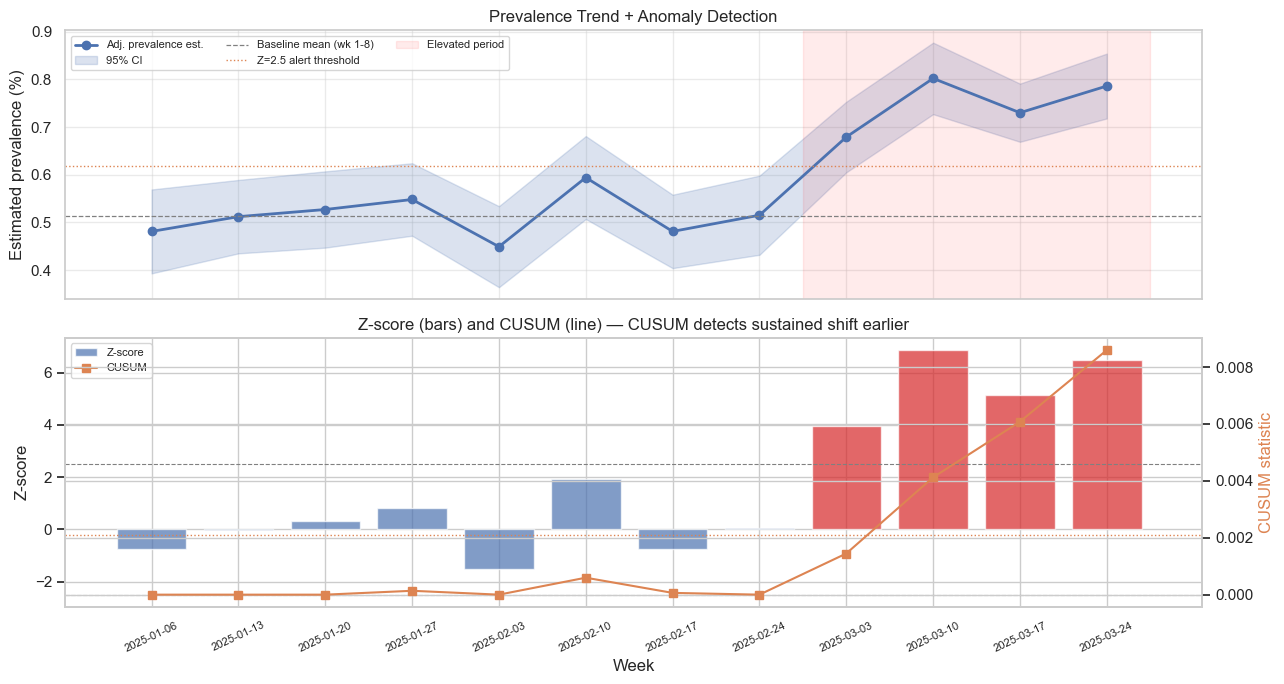

Z-score alert triggered at week(s): ['2025-03-03', '2025-03-10', '2025-03-17', '2025-03-24']
CUSUM alert triggered at week(s):   ['2025-03-10', '2025-03-17', '2025-03-24']
(Elevated period began: 2025-03-03)


In [9]:
# ─── Prevalence trend with anomaly detection ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

wk_idx   = np.arange(n_weeks)
prev_est = scorecard['adj_prevalence_pct'].values
ci_hw    = scorecard['ci_half_width_pp'].values

# Rolling baseline (first 8 weeks)
baseline_mean = prev_est[:8].mean()
baseline_std  = prev_est[:8].std()

z_scores = (prev_est - baseline_mean) / baseline_std

# CUSUM
k        = 0.5 * baseline_std  # reference value (half the expected shift)
cusum    = np.zeros(n_weeks)
for t in range(1, n_weeks):
    cusum[t] = max(0, cusum[t-1] + (prev_est[t] - baseline_mean) / 100 - k / 100)
cusum_threshold = 5 * baseline_std / 100

# Top: prevalence trend
axes[0].plot(wk_idx, prev_est, 'o-', lw=2, color='#4C72B0', label='Adj. prevalence est.')
axes[0].fill_between(wk_idx, prev_est - ci_hw, prev_est + ci_hw,
                     alpha=0.2, color='#4C72B0', label='95% CI')
axes[0].axhline(baseline_mean, ls='--', color='gray', lw=0.9, label='Baseline mean (wk 1-8)')
axes[0].axhline(baseline_mean + 2.5 * baseline_std, ls=':', color='#DD8452',
                lw=1.0, label='Z=2.5 alert threshold')

# Shade the elevated period
axes[0].axvspan(7.5, n_weeks - 0.5, alpha=0.08, color='red', label='Elevated period')
axes[0].set_ylabel('Estimated prevalence (%)')
axes[0].set_title('Prevalence Trend + Anomaly Detection')
axes[0].legend(fontsize=8, ncol=3)
axes[0].grid(True, alpha=0.4)

# Bottom: Z-score and CUSUM
axes[1].bar(wk_idx, z_scores,
            color=['#d62728' if abs(z) > 2.5 else '#4C72B0' for z in z_scores],
            alpha=0.7, label='Z-score')
ax_cusum = axes[1].twinx()
ax_cusum.plot(wk_idx, cusum, 's-', color='#DD8452', lw=1.5, label='CUSUM')
ax_cusum.axhline(cusum_threshold, ls=':', color='#DD8452', lw=1.0)
ax_cusum.set_ylabel('CUSUM statistic', color='#DD8452')

axes[1].axhline(2.5,  ls='--', color='gray', lw=0.8)
axes[1].axhline(-2.5, ls='--', color='gray', lw=0.8)
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Z-score')
axes[1].set_title('Z-score (bars) and CUSUM (line) — CUSUM detects sustained shift earlier')
axes[1].set_xticks(wk_idx)
axes[1].set_xticklabels(scorecard['week'], rotation=25, fontsize=8)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_cusum.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/09_trend_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

# Which week did CUSUM trigger?
cusum_trigger = np.where(cusum > cusum_threshold)[0]
z_trigger     = np.where(np.abs(z_scores) > 2.5)[0]
print(f"Z-score alert triggered at week(s): {[scorecard['week'].iloc[i] for i in z_trigger]}")
print(f"CUSUM alert triggered at week(s):   {[scorecard['week'].iloc[i] for i in cusum_trigger]}")
print(f"(Elevated period began: {scorecard['week'].iloc[8]})")

---
## Summary: metrics decision guide

```
Question                                    Metric to use
─────────────────────────────────────────── ──────────────────────────────────────
How much harm is on the platform right now? HT prevalence estimate + 95% CI

Is harm increasing / decreasing this week?  CUSUM statistic (preferred over Z-score
                                            for detecting slow, sustained shifts)

Did our new classifier improve detection?   TPR / recall delta between versions,
                                            measured on held-out gold review set

Is our review queue accurate?               Confirmation rate (target ≥ 75%)
                                            If low: threshold too permissive

Are we enforcing on what we find?           Enforcement rate + Gap rate by vertical
                                            High gap → queue backlog or policy gap

Are we over-enforcing (FP actions)?         Reversal rate on appeals
                                            High rate → threshold too aggressive

How responsive is the pipeline?             Time-to-action p50 and p95
                                            p95 > 24h for CSAM-adjacent → escalate

Did a policy change reduce harm?            A/B test: adjusted prevalence delta
                                            with power analysis from notebook 07

Should we trust the off-platform signal?    Bayesian posterior lift (notebook 08)
                                            Validate FPR before acting on signal
```
